## ***Lab 3: Univariate Volatility Modelling 🎢***

In [1]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 4.6 MB/s eta 0:00:00


In [2]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.api import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.stattools import (
    acf, pacf, q_stat, adfuller, kpss
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from arch.univariate import EWMAVariance, ConstantMean
from arch.unitroot import PhillipsPerron
from scipy.stats import jarque_bera
from scipy.optimize import minimize
import plotly.graph_objects as go
from plotly.subplots import make_subplots


***Set default layout.***

In [3]:
default_layout = dict(
    xaxis=dict(titlefont=dict(size=25), tickfont=dict(size=20), showgrid=False),
    yaxis=dict(titlefont=dict(size=25), tickfont=dict(size=20), showgrid=False, zeroline=False),
    font=dict(family="Serif", size=20, color="black"),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    legend=dict(font=dict(size=18), bgcolor='rgba(255,255,255,0.5)', bordercolor='black', borderwidth=1),
    margin=dict(t=80, l=60, r=60, b=60)
)

# Functions

In [4]:
def SACF_SPACF_plotly(series, lag_max=24, ylim=(-0.15, 0.15)):
    # Compute ACF and PACF with confidence intervals
    acf_vals, acf_conf = acf(series, nlags=lag_max, alpha=0.05)
    pacf_vals, pacf_conf = pacf(series, nlags=lag_max, alpha=0.05, method='ols')

    lags = list(range(1, lag_max+1))

    fig = make_subplots(rows=1, cols=2, subplot_titles=("SACF", "SPACF"))

    # ACF: bars + CIs
    fig.add_trace(go.Bar(
        x=lags, y=acf_vals[1:], marker_color='blue', opacity=0.7,
        showlegend=False
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=lags, y=acf_conf[1:,0], mode='lines',
        line=dict(color='grey', width=2),
        showlegend=False
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=lags, y=acf_conf[1:,1], mode='lines',
        line=dict(color='grey', width=2),
        fill='tonexty', fillcolor='rgba(128,128,128,0.15)',
        showlegend=False
    ), row=1, col=1)

    # PACF: bars + CIs
    fig.add_trace(go.Bar(
        x=lags, y=pacf_vals[1:], marker_color='blue', opacity=0.7,
        showlegend=False
    ), row=1, col=2)

    fig.add_trace(go.Scatter(
        x=lags, y=pacf_conf[1:,0], mode='lines',
        line=dict(color='grey', width=2),
        showlegend=False
    ), row=1, col=2)

    fig.add_trace(go.Scatter(
        x=lags, y=pacf_conf[1:,1], mode='lines',
        line=dict(color='grey', width=2),
        fill='tonexty', fillcolor='rgba(128,128,128,0.15)',
        showlegend=False
    ), row=1, col=2)

    # Layout
    fig.update_yaxes(range=ylim, row=1, col=1)
    fig.update_yaxes(range=ylim, row=1, col=2)

    fig.update_layout(
        title=dict(text='SACF and SPACF', x=0.5, font=dict(size=28, family='Serif', color='black')),
        font=dict(family="Serif", size=18, color="black"),
        plot_bgcolor='rgba(0,0,0,0)',
        paper_bgcolor='rgba(0,0,0,0)',
        margin=dict(t=80, l=60, r=60, b=60),
        showlegend=False
    )

    fig.show()

In [5]:
def SACF_SPACF(series, lag_max = 24, alpha_level = 0.05, model_df = 0):
    """
    Compute the sample autocorrelation function (SACF), sample partial autocorrelation function (SPACF),
    and Ljung-Box Q-statistics for a time series.

    This function calculates the ACF and PACF values along with their corresponding confidence intervals
    for lags 1 through `lag_max` using the provided significance level (`alpha_level`). In addition, it
    computes the Ljung-Box Q-statistic and associated p-values (excluding lag 0). Set `model_df`
    to the number of dof lost.

    """

    # Calculate ACF and PACF with confidence intervals
    acf_vals, acf_confint = acf(series, nlags=lag_max, alpha=alpha_level)
    pacf_vals, pacf_confint = pacf(series, nlags=lag_max, alpha=alpha_level, method='ols')

    # Calculate Ljung-Box statistics and p-values
    lb_results = sm.stats.acorr_ljungbox(
        series,
        lags=range(1, lag_max + 1),
        model_df=model_df,
        return_df=True
    )

    # Build the results DataFrame
    df_acf_pacf = pd.DataFrame({
        "Lag": np.arange(1, lag_max + 1),
        "ACF": acf_vals[1:],
        "ACF_lower": acf_confint[1:, 0],
        "ACF_upper": acf_confint[1:, 1],
        "PACF": pacf_vals[1:],
        "PACF_lower": pacf_confint[1:, 0],
        "PACF_upper": pacf_confint[1:, 1],
        "Q-stat": lb_results["lb_stat"].values,
        "Q-stat Prob": lb_results["lb_pvalue"].values.round(6)
    })

    # Set the index to 'Lag' and extract the main columns
    df_acf_pacf.set_index("Lag", inplace=True)
    df_acf_pacf_small = df_acf_pacf[["ACF", "PACF", "Q-stat", "Q-stat Prob"]].copy()

    return df_acf_pacf_small

# 1) Data Exploration

In [6]:
df = pd.read_excel("/content/SP500.xlsx", sheet_name=1)
df.rename(columns={
    'observation_date': 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace = True)
df = df.dropna()
df = df[['SP500']].copy()
df['return'] = df['SP500'].pct_change() * 100
df = df.dropna(subset=['return'])

In [7]:
fig_returns = go.Figure()
fig_returns.add_trace(go.Scatter(
    x=df.index, y=df['return'],
    mode='lines',
    name='Returns',
    line=dict(color='blue', width=1.5),
))
fig_returns.update_layout(
    title=dict(
        text='S&P 500 Returns',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),

    plot_bgcolor='rgba(0,0,0,0)',

    paper_bgcolor='rgba(0,0,0,0)',

    xaxis=dict(
        title='Date',
        titlefont=dict(size=25),
        tickfont=dict(size=25),
        showgrid=False
    ),
    yaxis=dict(
        title='S&P 500 Returns (%)',
        titlefont=dict(size=25),
        tickfont=dict(size=25),
        showgrid=False,
        zeroline=False
    ),
    font=dict(
        family="Serif",
        size=25,
        color="black"
    ),
)

fig_returns.show()

# 2) Stylised Facts of Conditional Heteroskedasticity

**1) Leptokurtic Distribution**

In [8]:
fig_histogram = go.Figure()

fig_histogram.add_trace(go.Histogram(
    x=df['return'],
    nbinsx=200,
    marker=dict(color='blue', line=dict(color='black', width=1)),
    name='Returns',
))

fig_histogram.update_layout(
    title=dict(
        text='Histogram (estimate)',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),

    plot_bgcolor='rgba(0,0,0,0)',

    paper_bgcolor='rgba(0,0,0,0)',

    xaxis=dict(
        title='S&P 500 Returns (%)',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False
    ),
    yaxis=dict(
        title='Frequency',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False,
        zeroline=False
    ),
    font=dict(
        family="Serif",
        size=20,
        color="black"
    ),
    bargap=0.01
)

fig_histogram.show()

In [9]:
kurt = df['return'].kurt() + 3
print(f'Kurtosis of Returns: {kurt}')

Kurtosis of Returns: 17.48658167387046


**2) Volatility Clustering**

In [10]:
returns = df['return'].copy()
squared_returns = returns ** 2
cubed_returns = returns ** 3

In [11]:
fig_clustering = make_subplots(rows=1, cols=2, subplot_titles=(
    "Squared Daily US Stock Returns", "Cubed Daily US Stock Returns"))

# Squared returns
fig_clustering.add_trace(go.Scatter(
    x=df.index, y=squared_returns,
    mode='lines',
    name='Squared Returns',
    line=dict(color='blue', width=1.5)
), row=1, col=1)

# Cubed returns
fig_clustering.add_trace(go.Scatter(
    x=df.index, y=cubed_returns,
    mode='lines',
    name='Cubed Returns',
    line=dict(color='blue', width=1.5)
), row=1, col=2)

# Layout
fig_clustering.update_layout(
    title=dict(
        text='Transformed Daily US Stock Returns',
        x=0.5,
        font=dict(size=26, family='Serif', color='black')
    ),
    plot_bgcolor='rgba(0,0,0,0)',

    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(
        family="Serif",
        size=18,
        color="black"
    ),
    showlegend=False,
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_clustering.update_xaxes(title_text="Date", row=1, col=1)
fig_clustering.update_yaxes(title_text="Squared Returns", row=1, col=1)

fig_clustering.update_xaxes(title_text="Date", row=1, col=2)
fig_clustering.update_yaxes(title_text="Cubed Returns", row=1, col=2)

fig_clustering.show()


In [12]:
acf_pacf_squared = SACF_SPACF(squared_returns, lag_max=24)
SACF_SPACF_plotly(squared_returns, lag_max=24, ylim = [-0.15,0.6])

**3) Leverage Effect**


$\left\{ \mathrm{Corr}(r_t, r_{t+i}^2) \right\}_{i=1}^{12}$


In [13]:
serial_correlation = pd.DataFrame({
    "i": np.arange(1, 13),
    "Level,Squared(+i)": [
        np.corrcoef(
            pd.concat([df['return'], squared_returns.shift(-i)], axis=1).dropna().values.T
        )[0, 1]
        for i in range(1, 13)
    ]
})
serial_correlation

,i,"Level,Squared(+i)"
0,1,-0.082957
1,2,-0.156025
2,3,-0.096208
3,4,-0.126341
4,5,-0.065625
5,6,-0.148120
6,7,-0.009480
7,8,-0.069459
8,9,-0.025984
9,10,-0.032029


# 3) Rolling Window Variance Forecast

In general, we assume

$$
r_t = \mu + \epsilon_t,
\quad
\text{where }
\epsilon_t = \sigma_t \, z_t,
$$

hence {$\epsilon_t$} comes from a conditional mean function model and we define

$$
\sigma_{t+1 \mid t}^2 (W)
\;=\;
\frac{1}{W}
\sum_{\tau=1}^{W}
\epsilon_{\,t+1-\tau}^2.
$$


Rolling window config.

In [14]:
W = 22

In [15]:
rw_df = df.copy()

Rolling window.

In [16]:
rw_df[f'MW_mean_{W}'] = rw_df['return'].rolling(window=W).mean()
rw_df[f'residual_{W}'] = rw_df['return'] - rw_df[f'MW_mean_{W}']
rw_df[f'squared_residual_{W}'] = (rw_df[f'residual_{W}'])**2
rw_df[f'MW_variance_forecasts{W}'] = rw_df[f'squared_residual_{W}'].rolling(window=W).mean()
rw_df[f'MW_vol_forecasts{W}'] = np.sqrt(rw_df[f'MW_variance_forecasts{W}'])
rw_df

,SP500,return,MW_mean_22,residual_22,squared_residual_22,MW_variance_forecasts22,MW_vol_forecasts22
date,,,,,,,
2015-03-19,2089.27,-0.487259,NaN,NaN,NaN,NaN,NaN
2015-03-20,2108.10,0.901272,NaN,NaN,NaN,NaN,NaN
2015-03-23,2104.42,-0.174565,NaN,NaN,NaN,NaN,NaN
2015-03-24,2091.50,-0.613946,NaN,NaN,NaN,NaN,NaN
2015-03-25,2061.05,-1.455893,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2025-03-11,5572.07,-0.756782,-0.392697,-0.364085,0.132558,1.118111,1.057408
2025-03-12,5599.30,0.488687,-0.327462,0.816149,0.666100,1.103985,1.050707
2025-03-13,5521.52,-1.389102,-0.421115,-0.967987,0.936999,1.132906,1.064381


In [17]:
fig_rw = go.Figure()

# Plot returns
fig_rw.add_trace(go.Scatter(
    x=rw_df.index,
    y=rw_df[f'squared_residual_{W}'],
    mode='lines',
    name='Squared Residual',
    line=dict(color='steelblue', width=1.5),
    opacity=0.5
))

# Plot rolling realized volatility
fig_rw.add_trace(go.Scatter(
    x=rw_df.index,
    y=rw_df[f'MW_variance_forecasts{W}'],
    mode='lines',
    name=f'Rolling Variance (W={W})',
    line=dict(color='firebrick', width=2.0)
))

# Layout and style
fig_rw.update_layout(
    title=dict(
        text=f'Rolling-Window Predicted Variance (W={W})',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),
    xaxis=dict(
        title='Date',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False
    ),
    yaxis=dict(
        title='Squared Residual / Variance',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False,
        zeroline=False,
    ),
    font=dict(
        family="Serif",
        size=20,
        color="black"
    ),

    plot_bgcolor='rgba(0,0,0,0)',

    paper_bgcolor='rgba(0,0,0,0)',

    legend=dict(
        font=dict(size=18),
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='black',
        borderwidth=1
    ),
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_rw.show()

# 4) RiskMetrics (Exponential Variance Smoother)

In the *RiskMetrics* framework, the next‐period variance forecast at time $t$ is modeled as an exponentially‐weighted average of all past squared innovations:
$$
  \sigma^2_{t+1 \mid t}(\lambda)
  \;=\; (1 - \lambda) \sum_{\tau=1}^{\infty} \lambda^{\tau - 1} \,\epsilon_{t+1-\tau}^2,
  \quad\text{where } 0 < \lambda < 1.
$$

In practice, one usually writes the model in its convenient recursive form:
$$
  \sigma^2_{t+1 \mid t}(\lambda)
  \;=\; (1 - \lambda)\,\epsilon_{t}^2
        \;+\; \lambda\,\sigma^2_{t \mid t-1}(\lambda).
$$


# 4a) **Fix $\lambda$**

RiskMetrics config.

In [18]:
lambda_ = 0.94

In [19]:
rm_df = df.copy()

In [20]:
rm_df.index = pd.DatetimeIndex(rm_df.index)
rm_df.index.freq = None

Unpacked.

In [21]:
variance_rm = [np.nan] * len(rm_df)

In [22]:
rm_df['epsilon_rm'] = (rm_df['return'] - np.mean(rm_df['return']))
rm_df['epsilon_squared_rm'] = rm_df['epsilon_rm']**2

We need to fix the variance ($\sigma^2$) in order to start the recursion. We pick a reasonable initial guess.

In [23]:
initial_var = np.mean(rm_df['epsilon_rm'].iloc[:W]**2) #W−1->21
variance_rm[W-1] = initial_var #21 --> 22nd

Recursively compute the predicted variance.

In [24]:
for t in range(W, len(rm_df)):
    eps_t_minus_1_sq = rm_df['epsilon_squared_rm'].iloc[t-1]
    variance_rm[t] = lambda_ * variance_rm[t-1] + (1 - lambda_) * eps_t_minus_1_sq

rm_df['predicted_variance_rm'] = variance_rm
rm_df['predicted_volatility_rm'] = np.sqrt(rm_df['predicted_variance_rm'])

In [25]:
fig_rm = go.Figure()

fig_rm.add_trace(go.Scatter(
    x=rm_df.index,
    y=rm_df['epsilon_squared_rm'],
    mode='lines',
    name='Squared Residual',
    line=dict(color='steelblue', width=1.5),
    opacity=0.5
))

fig_rm.add_trace(go.Scatter(
    x=rm_df.index,
    y=rm_df['predicted_variance_rm'],
    mode='lines',
    name=f'RiskMetrics (lambda = {lambda_})',
    line=dict(color='firebrick', width=2.0)
))

fig_rm.update_layout(
    title=dict(
        text=f'RiskMetrics Predicted Variance (lambda = {lambda_})',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),
    xaxis=dict(
        title='Date',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False
    ),
    yaxis=dict(
        title='Squared Residual / Variance',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False,
        zeroline=False,
    ),
    font=dict(
        family="Serif",
        size=20,
        color="black"
    ),

    plot_bgcolor='rgba(0,0,0,0)',

    paper_bgcolor='rgba(0,0,0,0)',

    legend=dict(
        font=dict(size=18),
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='black',
        borderwidth=1
    ),
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_rm.show()

# 4b) **Estimate $\lambda$**

In [26]:
model_SES = SimpleExpSmoothing(rm_df['epsilon_squared_rm'])
fitted_model_SES = model_SES.fit(optimized=True)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



In [27]:
print(fitted_model_SES.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:     epsilon_squared_rm   No. Observations:                 2514
Model:             SimpleExpSmoothing   SSE                          45131.908
Optimized:                       True   AIC                           7263.714
Trend:                           None   BIC                           7275.373
Seasonal:                        None   AICC                          7263.730
Seasonal Periods:                None   Date:                 Wed, 01 Jul 2026
Box-Cox:                        False   Time:                         22:38:52
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.2897622                alpha                 True
initial_level              0.2842783                

In [28]:
lambda_SES = 1 - fitted_model_SES.model.params['smoothing_level']
lambda_SES

np.float64(0.7102377593752001)

# 5) ARCH Models

$$
\begin{aligned}
r_{t+1} &= \mu + \epsilon_{t+1},\\
\epsilon_{t+1} &= r_{t+1} \;-\; \mathbb{E}[r_{t+1} \mid \text{F}_t], \\
\epsilon_{t+1} &= \sigma_{t+1 \mid t}\, z_{t+1}, \quad z_{t+1} \sim \text{N}(0,1),\\
\sigma_{t+1 \mid t}^2 &= \alpha_0 \;+\; \alpha_1 \,\epsilon_t^2,
\end{aligned}
$$

where:

- $ \mu $ is a constant mean,
- $ \alpha_0 > 0 $ and $ \alpha_1 \ge 0 $ ensure nonnegative variance,
- for stationarity, we require $ \alpha_1 < 1 $,
- $ \text{F}_t $ denotes the information set up to time $t$,
- $ r_{t+1} $ is the return at time $ t+1 $, and $ \epsilon_{t+1} $ is its unpredictable component.


In [29]:
arch_df = df.copy()

In [30]:
mle_arch = pd.DataFrame()
mle_arch['Y'] = arch_df['return'].copy()
mle_arch.reset_index(drop=True, inplace=True)

In [31]:
mu_guess     = mle_arch['Y'].mean(skipna=True)
alpha0_guess = 0.01
alpha1_guess = 0.5
init_params = [mu_guess, alpha0_guess, alpha1_guess]

In [32]:
def log_likelihood_arch1(params, df):
    """
    Computes the negative log-likelihood for an ARCH(1) model
    with a constant mean: Y_t = mu + epsilon_t,
    where sigma_t^2 = alpha_0 + alpha_1 * epsilon_{t-1}^2.

    params = [mu, alpha_0, alpha_1]
    df: DataFrame with a column 'Y'.
    """
    mu       = params[0]
    alpha_0  = params[1]
    alpha_1  = params[2]

    T = len(df)
    if T < 2:
        return 1e10

    epsilon_array = np.zeros(T)
    sigma_sq_array = np.zeros(T)

    # Initialization at t=0
    if not np.isnan(df.loc[0, 'Y']):
        epsilon_array[0] = df.loc[0, 'Y'] - mu
        sigma_sq_array[0] = alpha_0 + alpha_1 * (epsilon_array[0])**2
    else:
        return 1e10

    for t in range(1, T):
        Y_t = df.loc[t, 'Y']
        if not np.isnan(Y_t):
            sigma_sq_array[t] = alpha_0 + alpha_1 * (epsilon_array[t-1])**2
            epsilon_array[t] = Y_t - mu
        else:
            sigma_sq_array[t] = sigma_sq_array[t-1]
            epsilon_array[t] = 0.0

    # Calculate log-likelihood
    log_like = 0.0
    for t in range(T):
        sig2 = sigma_sq_array[t]
        eps2 = epsilon_array[t]**2
        if sig2 <= 0:
            return 1e10  # penalize invalid variance
        log_like += (
            -0.5 * math.log(2 * math.pi)
            -0.5 * math.log(sig2)
            -0.5 * (eps2 / sig2)
        )

    # Return negative log-likelihood for minimization
    return -log_like

In [33]:
bounds = [
    (None, None),
    (1e-8, None), #alpha_0 > 0
    (1e-8, 0.9999) #alpha_1 in [0,1)
]

result = minimize(
    fun=log_likelihood_arch1,
    x0=init_params,
    args=(mle_arch,),
    method="L-BFGS-B",
    bounds=bounds
)

opt_mu, opt_alpha0, opt_alpha1 = result.x
neg_log_lik = result.fun

In [34]:
print("ARCH(1) parameter estimates:")
print("----------------------------")
print(f"mu       = {opt_mu:.6f}")
print(f"alpha_0  = {opt_alpha0:.6f}")
print(f"alpha_1  = {opt_alpha1:.6f}")
print(f"Negative Log-Likelihood = {neg_log_lik:.6f}")
print("Success? ", result.success)

ARCH(1) parameter estimates:
----------------------------
mu       = 0.099116
alpha_0  = 0.647810
alpha_1  = 0.511956
Negative Log-Likelihood = 3530.278267
Success?  True


In [35]:
arch = arch_model(
    arch_df['return'],
    mean='Constant',
    vol='ARCH',
    p=1,
    dist='normal'
)
results_arch = arch.fit()
epsilons_arch = results_arch.resid #from conditional mean model
epsilons_arch_squared = epsilons_arch**2
predicted_arch_volatility = results_arch.conditional_volatility
predicted_arch_variance = predicted_arch_volatility**2
print(results_arch.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 18041.331138091828
Iteration:      2,   Func. Count:     14,   Neg. LLF: 5905.679260302617
Iteration:      3,   Func. Count:     21,   Neg. LLF: 3565.415292136004
Iteration:      4,   Func. Count:     27,   Neg. LLF: 3530.2978863285507
Iteration:      5,   Func. Count:     31,   Neg. LLF: 3530.2978822776777
Iteration:      6,   Func. Count:     34,   Neg. LLF: 3530.2978822776868
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3530.2978822776777
            Iterations: 6
            Function evaluations: 34
            Gradient evaluations: 6
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                 return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -3530.30
Distribution:                  Normal   

In [36]:
fig_arch = go.Figure()

fig_arch.add_trace(go.Scatter(
    x=arch_df.index,
    y=epsilons_arch_squared,
    mode='lines',
    name='Squared Residual',
    line=dict(color='steelblue', width=1.5),
    opacity=0.5
))

fig_arch.add_trace(go.Scatter(
    x=arch_df.index,
    y=predicted_arch_variance,
    mode='lines',
    name=f'ARCH(1) Variance',
    line=dict(color='firebrick', width=2.0)
))

fig_arch.update_layout(
    title=dict(
        text=f'ARCH(1) Predicted Variance',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),
    xaxis=dict(
        title='Date',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False
    ),
    yaxis=dict(
        title='Squared Residual / Variance',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False,
        zeroline=False,
    ),
    font=dict(
        family="Serif",
        size=20,
        color="black"
    ),

    plot_bgcolor='rgba(0,0,0,0)',

    paper_bgcolor='rgba(0,0,0,0)',

    legend=dict(
        font=dict(size=18),
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='black',
        borderwidth=1
    ),
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_arch.show()

# 6) GARCH Models

The GARCH(1,1) model is defined as:
$$ r_t = \mu + \epsilon_t, $$
$$ \epsilon_t = \sigma_t z_t, \quad z_t \sim \text{N}(0,1), $$
$$ \sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2. $$
where:

- $r_t$ is the return at time $t$,
- $\mu$ is the mean return,
- $\epsilon_t$ is the residual (innovation),
- $\sigma_t^2$ is the conditional variance,
- $z_t$ is a standard normal error term,
- $\omega > 0$, $\alpha \geq 0$, and $\beta \geq 0 $ are model parameters.
For stationarity, the condition $ \alpha + \beta < 1 $ must hold.

In [37]:
garch_df = df.copy()

In [38]:
mle_garch = pd.DataFrame()
mle_garch['Y'] = garch_df['return'].copy()
mle_garch.reset_index(drop=True, inplace=True)

In [39]:
mu_guess     = mle_garch['Y'].mean(skipna=True)
alpha0_guess = 0.01
alpha1_guess = 0.05
beta1_guess  = 0.8

init_params = [mu_guess, alpha0_guess, alpha1_guess, beta1_guess]

In [40]:
def log_likelihood_garch11(params, df):
    """
    Computes the negative log-likelihood for a GARCH(1,1) model
    with a constant mean: Y_t = mu + epsilon_t,
    where:
       sigma_t^2 = alpha_0 + alpha_1 * epsilon_{t-1}^2 + beta_1 * sigma_{t-1}^2.

    params = [mu, alpha_0, alpha_1, beta_1]
    df must have a column 'Y'.
    """
    mu       = params[0]
    alpha_0  = params[1]
    alpha_1  = params[2]
    beta_1   = params[3]

    T = len(df)
    if T < 2:
        return 1e10

    epsilon_array = np.zeros(T)
    sigma_sq_array = np.zeros(T)

    if not np.isnan(df.loc[0, 'Y']):
        epsilon_array[0] = df.loc[0, 'Y'] - mu
        sample_variance     = (mle_garch['Y'].std(skipna=True))**2
        sigma_sq_array[0] = alpha_0 + alpha_1 * (epsilon_array[0])**2 + (beta_1 * sample_variance)
    else:
        return 1e10

    for t in range(1, T):
        Y_t = df.loc[t, 'Y']
        if not np.isnan(Y_t):
            sigma_sq_array[t] = (
                alpha_0
                + alpha_1 * (epsilon_array[t-1])**2
                + beta_1  * sigma_sq_array[t-1]
            )
            epsilon_array[t] = Y_t - mu
        else:
            sigma_sq_array[t] = sigma_sq_array[t-1]
            epsilon_array[t] = 0.0

    # Compute the log-likelihood
    log_like = 0.0
    for t in range(T):
        sig2 = sigma_sq_array[t]
        eps2 = epsilon_array[t]**2
        if sig2 <= 0:
            return 1e10  # penalize invalid variance
        # Normal log-density with mean 0, variance sig2
        log_like += (
            -0.5 * math.log(2.0 * math.pi)
            -0.5 * math.log(sig2)
            -0.5 * (eps2 / sig2)
        )

    return -log_like

bounds = [
    (None, None),    # mu
    (1e-8, None),    # alpha_0
    (1e-8, 0.9999),  # alpha_1
    (1e-8, 0.9999)   # beta_1
]

result = minimize(
    fun=log_likelihood_garch11,
    x0=init_params,
    args=(mle_garch,),
    method="L-BFGS-B",
    bounds=bounds
)

opt_mu, opt_alpha0, opt_alpha1, opt_beta1 = result.x
neg_log_lik = result.fun

print("GARCH(1,1) parameter estimates:")
print("------------------------------")
print(f"mu       = {opt_mu:.6f}")
print(f"alpha_0  = {opt_alpha0:.6f}")
print(f"alpha_1  = {opt_alpha1:.6f}")
print(f"beta_1   = {opt_beta1:.6f}")
print(f"Negative Log-Likelihood = {neg_log_lik:.6f}")
print("Success? ", result.success)

GARCH(1,1) parameter estimates:
------------------------------
mu       = 0.080767
alpha_0  = 0.037657
alpha_1  = 0.178116
beta_1   = 0.792639
Negative Log-Likelihood = 3233.002966
Success?  True


In [41]:
bounds = [
    (None, None),    # mu
    (None, None),    # alpha_0
    (None, None),  # alpha_1
    (None, None)   # beta_1
]

result = minimize(
    fun=log_likelihood_garch11,
    x0=init_params,
    args=(mle_garch,),
    method="L-BFGS-B",
    bounds=bounds
)

opt_mu, opt_alpha0, opt_alpha1, opt_beta1 = result.x
neg_log_lik = result.fun

print("GARCH(1,1) parameter estimates without constraints:")
print("------------------------------")
print(f"mu       = {opt_mu:.6f}")
print(f"alpha_0  = {opt_alpha0:.6f}")
print(f"alpha_1  = {opt_alpha1:.6f}")
print(f"beta_1   = {opt_beta1:.6f}")
print(f"Negative Log-Likelihood = {neg_log_lik:.6f}")
print("Success? ", result.success)

GARCH(1,1) parameter estimates without constraints:
------------------------------
mu       = 0.080767
alpha_0  = 0.037661
alpha_1  = 0.178129
beta_1   = 0.792627
Negative Log-Likelihood = 3233.002965
Success?  True


In [42]:
garch = arch_model(
    garch_df['return'],
    mean='Constant',
    vol='GARCH',
    p=1,
    q=1,
    dist='normal'
)
results_garch = garch.fit()
epsilons_garch = results_garch.resid
epsilons_garch_squared = epsilons_garch**2
predicted_garch_volatility = results_garch.conditional_volatility
predicted_garch_variance = predicted_garch_volatility**2
print(results_garch.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 26836.214866250106
Iteration:      2,   Func. Count:     16,   Neg. LLF: 14435.146760136073
Iteration:      3,   Func. Count:     26,   Neg. LLF: 5068.107460118004
Iteration:      4,   Func. Count:     33,   Neg. LLF: 3425.4000820025285
Iteration:      5,   Func. Count:     39,   Neg. LLF: 10045.49271539682
Iteration:      6,   Func. Count:     45,   Neg. LLF: 3267.0402199421014
Iteration:      7,   Func. Count:     51,   Neg. LLF: 3232.8290515916524
Iteration:      8,   Func. Count:     56,   Neg. LLF: 3232.791493898386
Iteration:      9,   Func. Count:     61,   Neg. LLF: 3232.7892207811915
Iteration:     10,   Func. Count:     66,   Neg. LLF: 3232.78903762789
Iteration:     11,   Func. Count:     71,   Neg. LLF: 3232.7890365778503
Iteration:     12,   Func. Count:     75,   Neg. LLF: 3232.789036577672
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3232.7890365778503
            Iteration

In [43]:
fig_garch = go.Figure()

fig_garch.add_trace(go.Scatter(
    x=garch_df.index,
    y=epsilons_garch_squared,
    mode='lines',
    name='Squared Residual',
    line=dict(color='steelblue', width=1.5),
    opacity=0.5
))

fig_garch.add_trace(go.Scatter(
    x=garch_df.index,
    y=predicted_garch_variance,
    mode='lines',
    name=f'GARCH(1,1) Variance',
    line=dict(color='firebrick', width=2.0)
))

fig_garch.update_layout(
    title=dict(
        text=f'GARCH(1,1) Predicted Variance',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),
    xaxis=dict(
        title='Date',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False
    ),
    yaxis=dict(
        title='Squared Residual / Variance',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False,
        zeroline=False,
    ),
    font=dict(
        family="Serif",
        size=20,
        color="black"
    ),

    plot_bgcolor='rgba(0,0,0,0)',

    paper_bgcolor='rgba(0,0,0,0)',

    legend=dict(
        font=dict(size=18),
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='black',
        borderwidth=1
    ),
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_garch.show()

# 7) EGARCH

In [44]:
egarch_df = df.copy()

In [45]:
egarch = arch_model(
    egarch_df['return'],
    mean='Constant',
    vol='EGARCH',
    p=1,
    o=1,
    q=1,
    dist='normal'
)
results_egarch = egarch.fit()
epsilons_egarch = results_egarch.resid
epsilons_egarch_squared = epsilons_egarch**2
predicted_egarch_volatility = results_egarch.conditional_volatility
predicted_egarch_variance = predicted_egarch_volatility**2
print(results_egarch.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 19721618.878866542
Iteration:      2,   Func. Count:     17,   Neg. LLF: 22928006465.38791
Iteration:      3,   Func. Count:     27,   Neg. LLF: 19257.084915296793
Iteration:      4,   Func. Count:     38,   Neg. LLF: 95372.6726240197
Iteration:      5,   Func. Count:     46,   Neg. LLF: 54282962153.37468
Iteration:      6,   Func. Count:     54,   Neg. LLF: 3199.508791067504
Iteration:      7,   Func. Count:     61,   Neg. LLF: 3188.429501484925
Iteration:      8,   Func. Count:     67,   Neg. LLF: 3188.422665785185
Iteration:      9,   Func. Count:     73,   Neg. LLF: 3188.4224578222643
Iteration:     10,   Func. Count:     79,   Neg. LLF: 3188.4224187560876
Iteration:     11,   Func. Count:     85,   Neg. LLF: 3188.4224135188088
Iteration:     12,   Func. Count:     90,   Neg. LLF: 3188.422413520706
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3188.4224135188088
            Iterations:

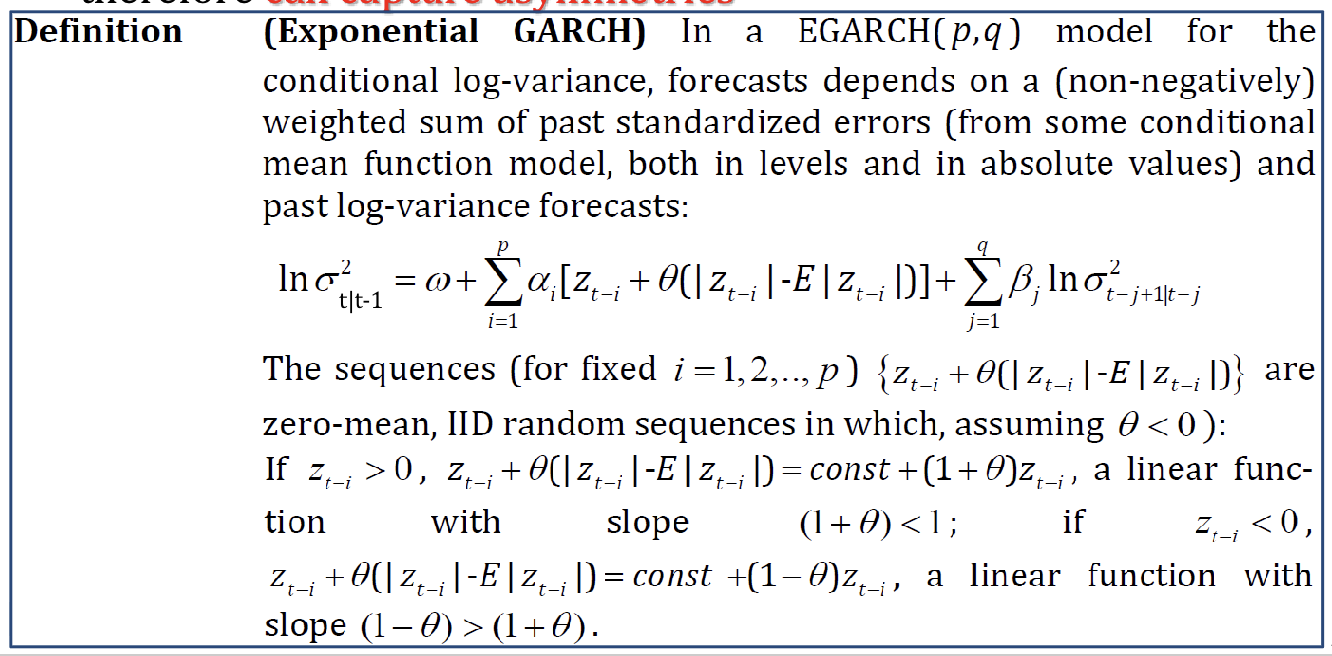

In [46]:
fig_egarch = go.Figure()

fig_egarch.add_trace(go.Scatter(
    x=egarch_df.index,
    y=epsilons_egarch_squared,
    mode='lines',
    name='Squared Residual',
    line=dict(color='steelblue', width=1.5),
    opacity=0.5
))

fig_egarch.add_trace(go.Scatter(
    x=egarch_df.index,
    y=predicted_egarch_variance,
    mode='lines',
    name=f'EGARCH(1,1) Variance',
    line=dict(color='firebrick', width=2.0)
))

fig_egarch.update_layout(
    title=dict(
        text=f'EGARCH(1,1) Predicted Variance',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),
    xaxis=dict(
        title='Date',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False
    ),
    yaxis=dict(
        title='Squared Residual / Variance',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False,
        zeroline=False,
    ),
    font=dict(
        family="Serif",
        size=20,
        color="black"
    ),

    plot_bgcolor='rgba(0,0,0,0)',

    paper_bgcolor='rgba(0,0,0,0)',

    legend=dict(
        font=dict(size=18),
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='black',
        borderwidth=1
    ),
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_egarch.show()

#  8) Comparison between CH models

In [47]:
fig_comp = go.Figure()

fig_comp.add_trace(go.Scatter(
    x=df.index,
    y=predicted_arch_variance,
    mode='lines',
    name='ARCH(1) Variance',
    line=dict(color='orange', width=2.0),
))

fig_comp.add_trace(go.Scatter(
    x=egarch_df.index,
    y=predicted_garch_variance,
    mode='lines',
    name=f'GARCH(1,1) Variance',
    line=dict(color='firebrick', width=2.0)
))

fig_comp.add_trace(go.Scatter(
    x=egarch_df.index,
    y=predicted_egarch_variance,
    mode='lines',
    name=f'EGARCH(1,1) Variance',
    line=dict(color='green', width=2.0)
))

fig_comp.update_layout(
    title=dict(
        text=f'Predicted Variance Comparison',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),
    xaxis=dict(
        title='Date',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False
    ),
    yaxis=dict(
        title='Variance',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False,
        zeroline=False,
    ),
    font=dict(
        family="Serif",
        size=20,
        color="black"
    ),

    plot_bgcolor='rgba(0,0,0,0)',

    paper_bgcolor='rgba(0,0,0,0)',

    legend=dict(
        font=dict(size=18),
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='black',
        borderwidth=1
    ),
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_comp.show()

#  9) Forecast Unbiasedness Regression

In [48]:
pred_df = df.copy()

In [49]:
pred_df['epsilon']= rm_df['epsilon_rm'].copy()
pred_df['epsilon_squared'] = pred_df['epsilon']**2
pred_df = pred_df[['epsilon_squared']]

In [50]:
pred_df = pd.concat([pred_df['epsilon_squared'], rw_df[f'MW_variance_forecasts{W}'], rm_df['predicted_variance_rm'], predicted_arch_variance, predicted_garch_variance, predicted_egarch_variance], axis=1, join='inner')
pred_df.columns = ['Epsilon Squared','Predicted Variance RW','Predicted Variance RM', 'Predicted Variance ARCH', 'Predicted Variance GARCH', 'Predicted Variance EGARCH']

In [51]:
pred_df.dropna(inplace=True)

In [52]:
pred_df

,Epsilon Squared,Predicted Variance RW,Predicted Variance RM,Predicted Variance ARCH,Predicted Variance GARCH,Predicted Variance EGARCH
date,,,,,,
2015-05-19,0.012158,0.398064,0.436239,0.669466,0.486009,0.461455
2015-05-20,0.019313,0.360667,0.410794,0.661516,0.426941,0.419106
2015-05-21,0.035295,0.360549,0.387306,0.666744,0.381683,0.390237
2015-05-22,0.072526,0.352037,0.366185,0.657100,0.344581,0.345646
2015-05-26,1.153716,0.396429,0.348565,0.701092,0.327352,0.357033
...,...,...,...,...,...,...
2025-03-11,0.644329,1.118111,1.465067,4.651054,2.640372,3.426581
2025-03-12,0.196044,1.103985,1.415822,1.022885,2.257360,3.145694
2025-03-13,2.059285,1.132906,1.342636,0.725486,1.858604,2.507060


In [53]:
Y = pred_df['Epsilon Squared']
test = dict()

for col in pred_df.columns:
    if col != 'Epsilon Squared':
        X = pred_df[col]
        X = sm.add_constant(X)
        model = sm.OLS(Y, X)
        results = model.fit()

        test[col] = {
            'summary': results.summary().as_text(),
            'f_test': None,
            't_test': None
        }

        # Perform and store the F-test
        try:
            f_test = results.f_test(f"const = 0, {col} = 1")
            test[col]['f_test'] = f_test
        except Exception as e:
            test[col]['f_test'] = f"Error performing F-test: {e}"

        # Perform and store the T-test
        try:
            t_test = results.t_test(f"{col} = 1")
            test[col]['t_test'] = t_test
        except Exception as e:
            test[col]['t_test'] = f"Error performing T-test: {e}"

In [54]:
column_name = 'Predicted Variance RW'
if column_name in test:
    print(f"Regression results for {column_name}:")
    print(test[column_name]['summary'])
    print("\nF-test for hypothesis that intercept = 0 and coefficient of regressor = 1:")
    print(test[column_name]['f_test'])
    print("\nT-test for hypothesis that the coefficient of regressor = 1:")
    print(test[column_name]['t_test'])
else:
    print(f"No results available for {column_name}")

Regression results for Predicted Variance RW:
                            OLS Regression Results                            
Dep. Variable:        Epsilon Squared   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     661.3
Date:                Wed, 01 Jul 2026   Prob (F-statistic):          2.04e-129
Time:                        22:39:22   Log-Likelihood:                -7278.1
No. Observations:                2472   AIC:                         1.456e+04
Df Residuals:                    2470   BIC:                         1.457e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

#  10) Import Realized Variance Data (To Have More Precision?)  

In [55]:
rv_df = pd.read_excel("/content/Daily_Variance.xlsx", sheet_name=0, skiprows=3)
rv_df.columns = ['date', '% Realized Variance']
rv_df['date'] = pd.to_datetime(rv_df['date'])
rv_df.set_index('date', inplace=True)
rv_df = rv_df.dropna()
rv_df = rv_df[['% Realized Variance']].copy()

In [56]:
rv_df

,% Realized Variance
date,
2015-03-18,0.552540
2015-03-19,0.563835
2015-03-20,0.603289
2015-03-23,0.587734
2015-03-24,0.606229
...,...
2025-01-17,1.171240
2025-01-21,1.201429
2025-01-22,0.774448


In [57]:
rv_df['% Realized Variance'] = rv_df['% Realized Variance'].shift(-1)

In [58]:
rv_df.dropna(inplace=True)
rv_df

,% Realized Variance
date,
2015-03-18,0.563835
2015-03-19,0.603289
2015-03-20,0.587734
2015-03-23,0.606229
2015-03-24,0.705115
...,...
2025-01-16,1.171240
2025-01-17,1.201429
2025-01-21,0.774448


In [59]:
pred_df_merged = pred_df.join(
    rv_df['% Realized Variance'],
    how='inner'
)

In [60]:
fig_rv = go.Figure()

fig_rv.add_trace(go.Scatter(
    x=pred_df_merged.index,
    y=pred_df_merged['Epsilon Squared'],
    mode='lines',
    name='Epsilon Squared',
    line=dict(color='steelblue', width=1.5),
    opacity=0.5,
    yaxis='y1'
))

fig_rv.add_trace(go.Scatter(
    x=pred_df_merged.index,
    y=pred_df_merged['% Realized Variance'],
    mode='lines',
    name='% Realized Variance',
    line=dict(color='firebrick', width=2.0),
    yaxis='y2'
))

fig_rv.update_layout(
    title=dict(
        text='Epsilon Squared vs Realized Variance',
        x=0.5,
        font=dict(size=30, family='Serif', color='black')
    ),
    xaxis=dict(
        title='Date',
        titlefont=dict(size=25),
        tickfont=dict(size=20),
        showgrid=False
    ),
    yaxis=dict(
        title='Epsilon Squared',
        titlefont=dict(size=25, color='steelblue'),
        tickfont=dict(size=20, color='steelblue'),
        showgrid=False,
        zeroline=False,
    ),
    yaxis2=dict(
        title='% Realized Variance',
        titlefont=dict(size=25, color='firebrick'),
        tickfont=dict(size=20, color='firebrick'),
        showgrid=False,
        zeroline=False,
        overlaying='y',
        side='right'
    ),
    font=dict(family="Serif", size=20, color="black"),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    legend=dict(
        font=dict(size=18),
        bgcolor='rgba(255,255,255,0.5)',
        bordercolor='black',
        borderwidth=1
    ),
    margin=dict(t=80, l=60, r=60, b=60)
)

fig_rv.show()

In [61]:
pred_df_merged

,Epsilon Squared,Predicted Variance RW,Predicted Variance RM,Predicted Variance ARCH,Predicted Variance GARCH,Predicted Variance EGARCH,% Realized Variance
date,,,,,,,
2015-05-19,0.012158,0.398064,0.436239,0.669466,0.486009,0.461455,0.396825
2015-05-20,0.019313,0.360667,0.410794,0.661516,0.426941,0.419106,0.388929
2015-05-21,0.035295,0.360549,0.387306,0.666744,0.381683,0.390237,0.387359
2015-05-22,0.072526,0.352037,0.366185,0.657100,0.344581,0.345646,0.440840
2015-05-26,1.153716,0.396429,0.348565,0.701092,0.327352,0.357033,0.471468
...,...,...,...,...,...,...,...
2025-01-16,0.066143,1.042205,0.903176,2.183587,1.201389,0.993473,1.171240
2025-01-17,0.908556,1.090721,0.852954,0.697163,1.006088,0.903361,1.201429
2025-01-21,0.690399,1.122285,0.856290,1.062381,0.985557,0.817473,0.774448


In [62]:
pred_df_merged.drop(columns=['Epsilon Squared'], inplace=True)

In [63]:
Y = pred_df_merged['% Realized Variance']
test = dict()

for col in pred_df_merged.columns:
    if col != '% Realized Variance':
        X = pred_df_merged[col]
        X = sm.add_constant(X)
        model = sm.OLS(Y, X)
        results = model.fit()

        test[col] = {
            'summary': results.summary().as_text(),
            'f_test': None,
            't_test': None
        }

        # Perform and store the F-test
        try:
            f_test = results.f_test(f"const = 0, {col} = 1")
            test[col]['f_test'] = f_test
        except Exception as e:
            test[col]['f_test'] = f"Error performing F-test: {e}"

        # Perform and store the T-test
        try:
            t_test = results.t_test(f"{col} = 1")
            test[col]['t_test'] = t_test
        except Exception as e:
            test[col]['t_test'] = f"Error performing T-test: {e}"

In [64]:
column_name = 'Predicted Variance RW'
if column_name in test:
    print(f"Regression results for {column_name}:")
    print(test[column_name]['summary'])
    print("\nF-test for hypothesis that intercept = 0 and coefficient of regressor = 1:")
    print(test[column_name]['f_test'])
    print("\nT-test for hypothesis that the coefficient of regressor = 1:")
    print(test[column_name]['t_test'])
else:
    print(f"No results available for {column_name}")

Regression results for Predicted Variance RW:
                             OLS Regression Results                            
Dep. Variable:     % Realized Variance   R-squared:                       0.960
Model:                             OLS   Adj. R-squared:                  0.960
Method:                  Least Squares   F-statistic:                 5.900e+04
Date:                 Wed, 01 Jul 2026   Prob (F-statistic):               0.00
Time:                         22:39:23   Log-Likelihood:                -2291.0
No. Observations:                 2435   AIC:                             4586.
Df Residuals:                     2433   BIC:                             4598.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------